# 1.4.1 规则、参数与初值

## 学习目标与先修知识

- 区分初值（initial condition）、参数（parameter）与模型结构（model structure）。
- 比较每段固定移除与每段比例移除的预测。
- 用独立算式与边界情形检查计算。

**先修知识**：[延迟怎样改变调节](../03-反馈延迟与层级/02-延迟怎样改变调节.ipynb)；百分比与乘方。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一段时间后，所追踪物质总量（tracked amount）从 10 U 变为 9 U。可能的解释至少有两个：每段固定移除 1 U；或者每段移除当前总量的 10%。它们在第一段恰好相同，以后也会相同吗？

先手算第二段。两种规则都没有外部输入（input），段长一致，起点一致。数值来自教学设定，不是实测清除常数。

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
first_end = 9
fixed_second = first_end - 1
fraction_second = first_end*(1-.1)
display(Markdown(show_table(['规则', '第二段末 / U'], [('固定量',fixed_second),('固定比例',fraction_second)])))

| 规则 | 第二段末 / U |
| --- | --- |
| 固定量 | 8 |
| 固定比例 | 8.1 |

## 模型假设

两组均用一个总量概括系统，忽略内部转化。固定规则每段移除 c U；比例规则每段移除当前量的 r，r 无量纲（dimensionless），即没有物理单位。A₀ 是开始时的总量，n 是段数。

初值决定从哪里开始；参数指定当前规则的系数；结构说明哪些量依赖哪些量。10% 改成 20% 是同一结构的参数改变，按比例改成固定量则改变结构。把记录保留两位小数属于观测（observation）或显示设置。

先选 A₀=10、c=1、r=0.1、n≤6，保证两组均非负。固定移除在总量耗尽后会给出负值，因此还要检查它能使用多少步。

## 数学解释与推导

固定移除每段都减 c，经过 n 段一共减 nc，因此 $A_n=A_0-nc$。比例移除每次留下 $1-r$，重复 n 次得到 $A_n=A_0(1-r)^n$。当 n=0 时均为 A₀，包括 r=1 的情况。

第 3 段末分别为 $10-3\times1=7$ 与 $10\times0.9^3=7.29$。乘方只是重复乘法；它为循环结果提供另一条核验路径。

比例组随着剩余量变小，每段移除量也变小；固定组没有这种依赖。不能仅凭第一次恰好一致就把两个结构合并。

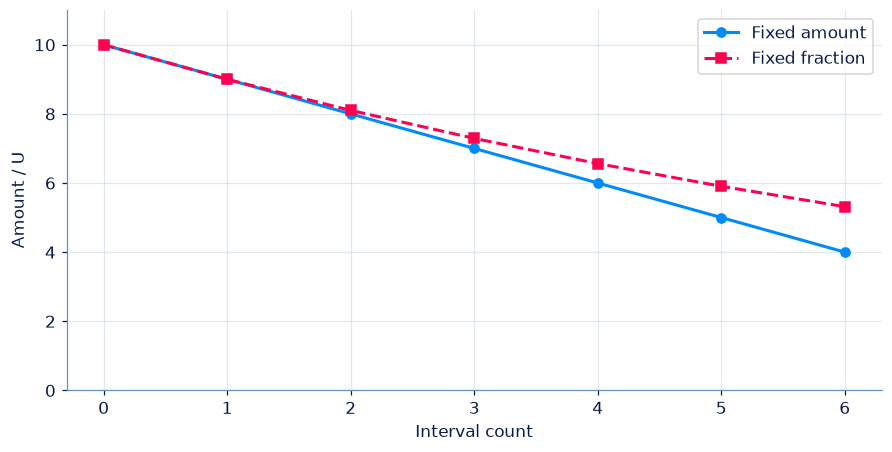

In [2]:
def compare_rules(initial, fixed, fraction, steps):
    fixed_path, fraction_path = [initial], [initial]
    for _ in range(steps):
        fixed_path.append(fixed_path[-1]-fixed)
        fraction_path.append(fraction_path[-1]*(1-fraction))
    return fixed_path, fraction_path

fixed_path, fraction_path = compare_rules(10,1,.1,6)
assert abs(fixed_path[3]-7)<1e-12 and abs(fraction_path[3]-7.29)<1e-12
for n,(a,b) in enumerate(zip(fixed_path,fraction_path)):
    assert abs(a-(10-n))<1e-12
    assert abs(b-10*.9**n)<1e-12
fig, ax = plt.subplots()
ax.plot(range(7),fixed_path,'o-',label='Fixed amount')
ax.plot(range(7),fraction_path,'s--',label='Fixed fraction')
ax.set(xlabel='Interval count',ylabel='Amount / U',ylim=(0,11))
ax.legend()
plt.show()

## 对照实验

现在只改起点为 20 U，仍保留原规则系数。再把固定组的观察范围延长到 12 段，记录从哪里开始产生负值。负值出现的位置标出了固定移除模型（model）需要改变规则的时刻。

In [3]:
a20,b20 = compare_rules(20,1,.1,3)
print('从 20 U 开始，第一段预测为', a20[1], '和', b20[1], 'U')
long_fixed,_ = compare_rules(10,1,.1,12)
negative_steps = [n for n,a in enumerate(long_fixed) if a<0]
print('固定规则首次出现负值：第', negative_steps[0], '段')
assert negative_steps[0] == 11
assert compare_rules(0,0,0,0) == ([0],[0])
assert compare_rules(4,0,1,2) == ([4,4,4],[4,0,0])

从 20 U 开始，第一段预测为 19 和 18.0 U
固定规则首次出现负值：第 11 段


## 结果解释

改变起点后，第一段就能区分两个固定候选；这给下一节的实验选择提供了依据。固定量规则在第 11 段出现负值，说明这个外推区间超出了总量模型的适用范围。

循环与闭式算式一致是在核对实现；它还没有核对真实机制。一个计算模型可以既被准确执行，又因假设不适用而预测错误。

[本章导览与各节入口](http://127.0.0.1:8000/chapters/01-04-模型假设与计算实验/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：改变的是哪一层假设

对“每段移除当前所追踪物质总量（tracked amount）的 10%”这一模型（model），以下哪些分类正确？

- **A.** 把初始总量从 10 改成 20，是改变初值（initial condition）。
- **B.** 把 10% 改成 20%，保持同一比例规则，是改变参数（parameter）。
- **C.** 把比例清除改成每段移除 1 U，是改变模型结构（model structure）。
- **D.** 把结果显示成两位小数，必然改变真实清除机制。

[作答：改变的是哪一层假设](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-change-class)

### 第 2 题 · Python 计算题：固定量与固定比例

比较两种没有外部输入（input）的清除模型（model）：每段移除 fixed U，或移除当前所追踪物质总量（tracked amount）的 fraction。给定相同初值（initial condition）和步数，返回两条轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    initial: float,
    fixed: float,
    fraction: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 两组共同的起点总量。 | U |
| `fixed` | `float` | 固定量规则每段移除的量。 | U/段 |
| `fraction` | `float` | 比例规则每段移除的比例。 | 无量纲 |
| `steps` | `int` | 更新次数。 | 段 |

**返回值**

按以下顺序返回元组：(fixed_path, fraction_path)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `fixed_path` | `list[float]` | 固定量轨迹，包含起点。 | U |
| `fraction_path` | `list[float]` | 比例轨迹，包含起点。 | U |

**计算规则**

固定量组每次减 fixed；比例组每次乘 (1−fraction)。返回 (fixed_path, fraction_path)。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ initial,fixed ≤ 1000；0 ≤ fraction ≤ 1；0 ≤ steps ≤ 1000。
- fixed×steps ≤ initial，保证固定量规则不越过零；两条列表长度均为 steps+1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 两组共同的起点总量。 | 10 | U |
| fixed | 固定量规则每段移除的量。 | 1 | U/段 |
| fraction | 比例规则每段移除的比例。 | 0.1 | 无量纲 |
| steps | 更新次数。 | 3 | 段 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 10
fixed = 1
fraction = 0.1
steps = 3

result = solve(initial, fixed, fraction, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| fixed_path | 固定量轨迹，包含起点。 | [10, 9, 8, 7] | U |
| fraction_path | 比例轨迹，包含起点。 | [10, 9, 8.1, 7.29] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([10, 9, 8, 7], [10, 9, 8.1, 7.29])
```

**样例解释**

第一段两组同为 9；之后比例组移除量从 1 减为 0.9、0.81，所以第三段末为 7.29，而固定组为 7。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定量与固定比例](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-compare-rules)

### 第 3 题 · 单项选择题：第一步相同就说明模型相同吗

初始 10 U，每段移除 1 U 或当前量的 10%，第一步都为 9 U。哪项解释合理？

- **A.** 两种模型结构（model structure）完全相同。
- **B.** 这一条件的第一步观测（observation）不足以区分两种规则，需要其他预测。
- **C.** 两种模型（model）在所有初值（initial condition）下都相同。
- **D.** 必须删除其中一个模型，否则无法计算。

[作答：第一步相同就说明模型相同吗](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-first-step)

### 第 4 题 · Python 计算题：第一次越过零发生在哪段

在固定移除规则中，起点为 initial，每段减去 fixed。只检查前 steps 段，返回第一次得到严格负所追踪物质总量（tracked amount）的段号，从 1 开始；若没有则返回 −1。

**函数与代码模板**

```python
def solve(
    initial: int,
    fixed: int,
    steps: int,
) -> int:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `int` | 初始总量。 | U |
| `fixed` | `int` | 每段移除量。 | U/段 |
| `steps` | `int` | 最多检查的段数。 | 段 |

**返回值**

直接返回 first_negative（int）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `first_negative` | `int` | 首个负值段号；未发生返回 −1。 | 段号 |

**计算规则**

等于零不算负；不裁剪负值。输入（input）为整数，因此不需要浮点阈值。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ initial,fixed,steps ≤ 10000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 初始总量。 | 5 | U |
| fixed | 每段移除量。 | 2 | U/段 |
| steps | 最多检查的段数。 | 4 | 段 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 5
fixed = 2
steps = 4

result = solve(initial, fixed, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| first_negative | 首个负值段号；未发生返回 −1。 | 3 | 段号 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 3
```

**样例解释**

第 1、2、3 段末为 3、1、−1，因此第一次失败在第 3 段。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：第一次越过零发生在哪段](http://127.0.0.1:8000/chapters/01-04-%E6%A8%A1%E5%9E%8B%E5%81%87%E8%AE%BE%E4%B8%8E%E8%AE%A1%E7%AE%97%E5%AE%9E%E9%AA%8C/practice/?question=p01-first-failure)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。